# Day 5 : House Prices Training Dataset

In [43]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")

## Question 1

In [62]:
summary_dict = {
    "Rows": df.shape[0],
    "Columns": df.shape[1],
    "Numeric Columns": len(df.select_dtypes(include='number').columns.tolist()),
    "Categorical Columns": len(df.select_dtypes(include=['object','category']).columns.tolist()),  # Had to use google to get select_dtypes()
    "Missing Values": df.isna().sum().sum()
}

summary = pd.DataFrame([summary_dict])
summary

,Rows,Columns,Numeric Columns,Categorical Columns,Missing Values
0,1460,81,38,43,7829


## Question 2

In [23]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

OR

In [26]:
print(f"1. Mean : {df['SalePrice'].mean()}")
print(f"2. Median : {df['SalePrice'].median()}")
print(f"3. Std : {df['SalePrice'].std()}")
print(f"4. Min : {df['SalePrice'].min()}")
print(f"5. Max : {df['SalePrice'].max()}")

1. Mean : 180921.19589041095
2. Median : 163000.0
3. Std : 79442.50288288662
4. Min : 34900
5. Max : 755000


## Question 3

1. Skewness of SalePrice = 1.880940746034036


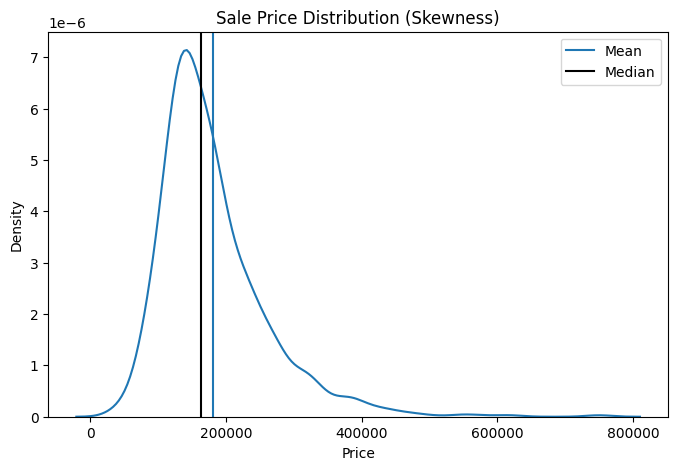

In [38]:
# I did not know how to do this so i googled it

skewness = skew(df['SalePrice'])
print(f"1. Skewness of SalePrice = {skewness}")

plt.figure(figsize=(8,5))
sns.kdeplot(df['SalePrice'])
plt.axvline(df['SalePrice'].mean(), label='Mean')
plt.axvline(df['SalePrice'].median(), color='black', label='Median')
plt.title("Sale Price Distribution (Skewness)")
plt.xlabel("Price")
plt.legend()
plt.show()

Kurtosis of SalePrice = 6.509812011089439


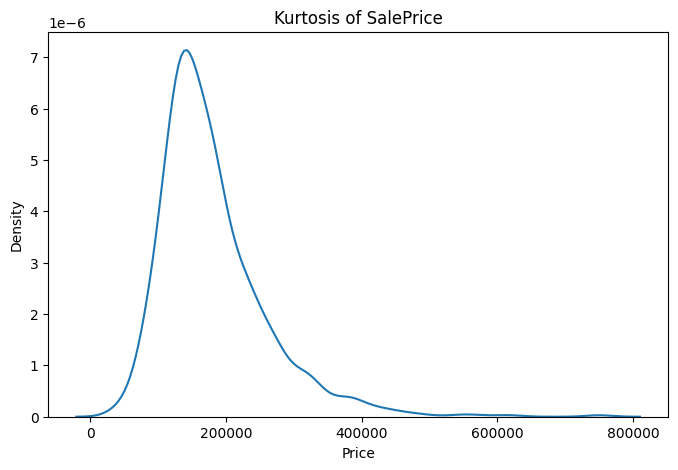

In [47]:
# Used google for this as weil because i havent done all this in a long time
kurtosis_val = kurtosis(df['SalePrice'])
print(f"Kurtosis of SalePrice = {kurtosis_val}")

plt.figure(figsize=(8,5))
sns.kdeplot(df['SalePrice'])
plt.title("Kurtosis of SalePrice")
plt.xlabel("Price")
plt.ylabel("Density")
plt.show()

No the distribution is not normal, it is positively skewed and leptokurtic. This means that it has heavier left tails and has a higher change of having extreme values.

## Question 4

In [65]:
cols = df.columns.tolist()
new_dict={
    'Column': cols,
    'Missing Count': df[cols].isna().sum().tolist()
}
missing_vals = pd.DataFrame(new_dict)
missing_vals['Missing Percent'] = missing_vals['Missing Count']*100/len(df)
missing_vals.sort_values(by='Missing Count', ascending=False, inplace=True)
missing_vals

,Column,Missing Count,Missing Percent
72,PoolQC,1453,99.520548
74,MiscFeature,1406,96.301370
6,Alley,1369,93.767123
73,Fence,1179,80.753425
25,MasVnrType,872,59.726027
...,...,...,...
27,ExterQual,0,0.000000
24,Exterior2nd,0,0.000000
23,Exterior1st,0,0.000000
22,RoofMatl,0,0.000000


1. The PoolQC columns has the most missing values.
2. I wouldnt drop it immediately because that would drop all the rows which may have important information and data of other columns still present.

## Question 5

In [107]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
correlations = df[numeric_cols].corrwith(df['SalePrice']).reset_index()  # Used google search lol
correlations.rename(columns={'index':"Feature", 0:'Correlation'}, inplace=True)
correlations.sort_values(by='Correlation', ascending=False, inplace=True)
correlations = correlations.iloc[1:]
correlations.iloc[:10]

,Feature,Correlation
4,OverallQual,0.790982
16,GrLivArea,0.708624
26,GarageCars,0.640409
27,GarageArea,0.623431
12,TotalBsmtSF,0.613581
13,1stFlrSF,0.605852
19,FullBath,0.560664
23,TotRmsAbvGrd,0.533723
6,YearBuilt,0.522897
7,YearRemodAdd,0.507101


## Question 6

In [112]:
correlations.sort_values(by='Correlation', ascending=True, inplace=True)
correlations.iloc[:10]

,Feature,Correlation
22,KitchenAbvGr,-0.135907
30,EnclosedPorch,-0.128578
1,MSSubClass,-0.084284
5,OverallCond,-0.077856
36,YrSold,-0.028923
15,LowQualFinSF,-0.025606
0,Id,-0.021917
34,MiscVal,-0.021190
18,BsmtHalfBath,-0.016844
10,BsmtFinSF2,-0.011378


## Quesiton 7

In [119]:
cols = ['OverallQual','GrLivArea','GarageCars','YearBuilt']
correlation = df[cols].corrwith(df['SalePrice']).reset_index()
correlation.rename(columns={'index':"Feature",0:'Correlation'},inplace=True)
correlation

,Feature,Correlation
0,OverallQual,0.790982
1,GrLivArea,0.708624
2,GarageCars,0.640409
3,YearBuilt,0.522897


Since OverallQual has the highest correlation, that feature will be most predictive.

## Question 8

In [ ]:
# Used google for this whole thing too lmaoo

q1 = np.percentile(df['GrLivArea'],25)
q3 = np.percentile(df['GrLivArea'],75)
iqr = q3-q1

print(f"Q1 = {q1}\nQ3 = {q3}\nIQR = {iqr}")

lower_bound = q1 - (1.5*iqr)
upper_bound = q3 + (1.5*iqr)

print(f"Lower Bound = {lower_bound}\nUpper Bound = {upper_bound}")

outliers = ((df['GrLivArea']<lower_bound) | (df['GrLivArea']>upper_bound)).sum()

print(f"Outlier Count = {outliers}")


Q1 = 1129.5
Q3 = 1776.75
IQR = 647.25
Lower Bound = 158.625
Upper Bound = 2747.625
Outlier Count = 31


## Question 9

In [134]:
qual_sale = df.groupby("OverallQual").agg(Avg_SalePrice=("SalePrice",'mean')).reset_index()
qual_sale.sort_values(by='OverallQual', ascending=True,inplace=True)
qual_sale

,OverallQual,Avg_SalePrice
0,1,50150.000000
1,2,51770.333333
2,3,87473.750000
3,4,108420.655172
4,5,133523.347607
5,6,161603.034759
6,7,207716.423197
7,8,274735.535714
8,9,367513.023256
9,10,438588.388889


1. Yes, the better the house quality, the higher is the avg sale price of the house
2. Yes, the relationship is linear. As discussed earlier OverallQual showed high positive correlation to SalePrice which shows that their relationship is in fact linera

## Question 10

I would keep the top 3 positively correlated features namely, OverallQual, GrLivArea, GarageCars, as they show a linear relationship with SalePrice and they would help justify and or predict the SalePrice of other houses as well.